# Notebook 4: NER Model Evaluation
**Luis Mitrovic Balbontín Archive**

Compares four NER models on two letters from the Mitrovic correspondence archive to justify
the selection of Stanza for the full corpus pipeline. Models tested: spaCy (en_core_web_sm),
Stanza (Stanford NLP), BERT-NER (dslim/bert-base-NER), and XLM-RoBERTa
(Davlan/xlm-roberta-base-ner-hrl).

**Input:** `data/raw/Phase2_50Letters.csv`
**Outputs:** `figures/fig6_ner_evaluation.png` · `data/processed/ner_evaluation_metrics.csv`

**Note:** Cells 3–8 load NER models (~1.5GB). Skip to Cell 9 if models are already cached.
Intermediate visualizations (Cell 33) are retained as process documentation and do not
follow the thesis visual standards.

In [ ]:
from pathlib import Path

BASE       = Path.cwd().parent
DATA_RAW   = BASE / "data" / "raw"
DATA_PROC  = BASE / "data" / "processed"
FIGURES    = BASE / "figures"

for folder in [DATA_PROC, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"DATA_RAW:  {DATA_RAW}")
print(f"DATA_PROC: {DATA_PROC}")
print(f"FIGURES:   {FIGURES}")

In [1]:
import sys
print(f"Python: {sys.version}")

# Check what's already installed
for lib in ['spacy', 'stanza', 'transformers', 'torch', 'pandas']:
    try:
        mod = __import__(lib)
        print(f"  {lib}: {mod.__version__}")
    except ImportError:
        print(f"  {lib}: NOT INSTALLED")

Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
  spacy: 3.8.11
  stanza: 1.11.1
  transformers: 5.3.0
  torch: 2.10.0+cpu
  pandas: 3.0.0


## 1. Environment Setup
Install dependencies and download NER models. Uses `sys.executable` to ensure packages install in the active kernel environment.

In [2]:
!pip install stanza transformers torch -q

In [3]:
import sys
!{sys.executable} -m pip install sentencepiece tiktoken -q

In [4]:
for lib in ['spacy', 'stanza', 'transformers', 'torch', 'pandas']:
    mod = __import__(lib)
    print(f"{lib}: {mod.__version__}")

spacy: 3.8.11
stanza: 1.11.1
transformers: 5.3.0
torch: 2.10.0+cpu
pandas: 3.0.0


In [9]:
# Download spaCy English model
!{sys.executable} -m spacy download en_core_web_sm -q

# Download Stanza English model
import stanza
stanza.download('en', processors='tokenize,ner', verbose=False)

print("All models downloaded.")

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
All models downloaded.


## 2. Load NER Models
Initialize all four models. Note: first run downloads model weights (~1.5GB total). Subsequent runs load from cache.

In [10]:
import pandas as pd
import spacy
import stanza
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

# Load spaCy model
nlp_spacy = spacy.load('en_core_web_sm')

# Load Stanza model
nlp_stanza = stanza.Pipeline('en', processors='tokenize,ner', verbose=False)

# Load Transformers NER pipeline (uses dslim/bert-base-NER by default)
nlp_transformers = pipeline('ner', model='dslim/bert-base-NER', aggregation_strategy='simple')

print("All 3 NER models loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All 3 NER models loaded.


## 3. Load Corpus and Select Test Letters
Load the intermediate selection of the correspondence CSV (50 letters) and select two letters for NER evaluation. Letter 1 was chosen for its formal style and clear entity references. Letter 2 for its informal style, heavy use of nicknames, and dense geographic references.

In [11]:
# Load CSV
df = pd.read_csv(DATA_RAW / "Phase2_50Letters.csv", sep=';', encoding='utf-8-sig')
print(f"Total letters: {len(df)}")
print(f"Languages: {df['Language'].value_counts().to_dict()}")

# Select test letters
letter_1 = df[df['Filename'] == 'MITRO3-S54-CARTA-004'].iloc[0]  # Baburizza (formal)
letter_2 = df[df['Filename'] == 'MITRO3-S35-CARTA-003'].iloc[0]  # John Jay (informal)

text_1 = letter_1['Content']
text_2 = letter_2['Content']

print(f"\n--- Letter 1: {letter_1['Filename']} ---")
print(f"From: {letter_1['From']} → To: {letter_1['To']} | Date: {letter_1['Date']}")
print(f"Length: {len(text_1)} chars")
print(f"Preview: {text_1[:200]}...")

print(f"\n--- Letter 2: {letter_2['Filename']} ---")
print(f"From: {letter_2['From']} → To: {letter_2['To']} | Date: {letter_2['Date']}")
print(f"Length: {len(text_2)} chars")
print(f"Preview: {text_2[:200]}...")

Total letters: 55
Languages: {'English': 40, 'German': 15}

--- Letter 1: MITRO3-S54-CARTA-004 ---
From: Baburizza & Company LTD → To: Luis Mitrovic Balbontín | Date: 24-11-1936
Length: 1884 chars
Preview: 160, Gresham House,
Bishopsgate,
London, E.C.2.
24th November, 1936.
Mr. Luis Mitrovich B.,
Legation de Chili,
VIENNA.
Austria.
Dear Lucho,
I was glad to get your letter of the 16th instant and to hea...

--- Letter 2: MITRO3-S35-CARTA-003 ---
From: John Jay
c/o Francis Boardman → To: Luis Mitrovic Balbontín | Date: 22-09-1941
Length: 2255 chars
Preview: Dear Lucho,

Muchas gracias for the splendid fotos; your new IKONTA is certainly a wonder. I liked the ones of Chiquita and Lollita immensely; will see that they reach their rightful destination as so...


## 4. NER Extraction: Letter 1 (Baburizza, 1936)
Run all four models on the formal letter and display raw entity output.

In [12]:
# RUN NER ON LETTER 1 (Baburizza) — All 3 models

# spaCy
doc_spacy = nlp_spacy(text_1)
ents_spacy = [(ent.text, ent.label_) for ent in doc_spacy.ents]

# Stanza
doc_stanza = nlp_stanza(text_1)
ents_stanza = [(ent.text, ent.type) for sent in doc_stanza.sentences for ent in sent.ents]

# Transformers 
raw_transformers = nlp_transformers(text_1)
ents_transformers = [(ent['word'], ent['entity_group']) for ent in raw_transformers]

# Display results side by side
print(f"{'='*60}")
print(f"NER RESULTS — {letter_1['Filename']}")
print(f"{'='*60}")

print(f"\n🔹 spaCy (en_core_web_sm) — {len(ents_spacy)} entities")
for text, label in ents_spacy:
    print(f"  {label:12s} → {text}")

print(f"\n🔹 Stanza — {len(ents_stanza)} entities")
for text, label in ents_stanza:
    print(f"  {label:12s} → {text}")

print(f"\n🔹 Transformers (BERT-NER) — {len(ents_transformers)} entities")
for text, label in ents_transformers:
    print(f"  {label:12s} → {text}")

NER RESULTS — MITRO3-S54-CARTA-004

🔹 spaCy (en_core_web_sm) — 25 entities
  CARDINAL     → 160
  PERSON       → Gresham House
  PRODUCT      → Bishopsgate
  GPE          → London
  ORDINAL      → 24th
  DATE         → November, 1936
  PERSON       → Luis Mitrovich B.
  ORG          → Legation de Chili
  GPE          → Austria
  ORG          → Dear Lucho
  ORDINAL      → 16th
  GPE          → Vienna
  PERSON       → Abovich
  LOC          → Franica
  CARDINAL     → two
  GPE          → angina
  LOC          → Franica
  GPE          → London
  GPE          → Marta
  PERSON       → Agustin Edwards
  DATE         → today
  NORP         → Chilean
  GPE          → London
  GPE          → Spain
  PERSON       → Reisser

🔹 Stanza — 26 entities
  CARDINAL     → 160
  GPE          → Gresham House
  GPE          → Bishopsgate
  GPE          → London
  DATE         → E.C.2.
24th November, 1936
  PERSON       → Luis Mitrovich
  PERSON       → de Chili
  GPE          → VIENNA
  GPE          → Austr

### 4.1 Fix: BERT-NER Tokenization
The default BERT-NER output fragments entities into subword tokens (e.g., "##bovich"). Switching aggregation strategy from 'simple' to 'max' resolves this by merging subword tokens into complete entities.

In [13]:
# Fix Transformers: use 'first' aggregation to avoid fragmented tokens
nlp_transformers_v2 = pipeline(
    'ner', 
    model='dslim/bert-base-NER', 
    aggregation_strategy='max'  # 'max' handles subword merging better
)

raw_t2 = nlp_transformers_v2(text_1)
ents_transformers_v2 = [(ent['word'], ent['entity_group'], round(ent['score'], 3)) for ent in raw_t2]

print(f"🔹 Transformers FIXED (BERT-NER, aggregation='max') — {len(ents_transformers_v2)} entities\n")
for text, label, score in ents_transformers_v2:
    print(f"  {label:6s} ({score:.3f}) → {text}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔹 Transformers FIXED (BERT-NER, aggregation='max') — 21 entities

  LOC    (0.985) → Gresham House
  LOC    (0.998) → Bishopsgate
  LOC    (1.000) → London
  LOC    (0.995) → E
  LOC    (0.999) → C
  PER    (0.926) → Luis Mitrovich B
  ORG    (0.942) → Legation de Chili
  LOC    (0.611) → VIENNA
  LOC    (1.000) → Austria
  PER    (0.983) → Lucho
  LOC    (1.000) → Vienna
  PER    (0.999) → Abovich
  PER    (0.995) → Franica
  PER    (0.999) → Abovich
  PER    (0.980) → Franica
  LOC    (1.000) → London
  PER    (0.991) → Marta
  PER    (0.997) → Agustin Edwards
  MISC   (1.000) → Chilean
  LOC    (1.000) → London
  LOC    (1.000) → Spain


## 5. Manual Annotation
I manually annotated all named entities in each letter. Annotation decisions are documented below. Labels used: PER (person), LOC (location), ORG (organization), MISC (demonyms, cultural references), DATE, ORD (ordinal).

Key decisions for Letter 1:
- "Lucho" → PER (nickname for Luis Mitrovic)
- "Bishopsgate" → LOC (street in London, included for completeness)
- "Chilean" → MISC (demonym, not a place)
- "angina" → excluded (common noun, not a named entity)
- "SI/WH" → excluded (likely OCR artifact from marginal note, not matching any known initials)

In [14]:
# MANUAL ANNOTATION — Letter 1 (MITRO3-S54-CARTA-004)

manual_annotations = [
    ("160 Gresham House", "LOC"),
    ("Bishopsgate", "LOC"),
    ("London", "LOC"),
    ("24th November 1936", "DATE"),
    ("Luis Mitrovich B.", "PER"),
    ("Legation de Chili", "ORG"),
    ("VIENNA", "LOC"),
    ("Austria", "LOC"),
    ("Lucho", "PER"),
    ("Austria", "LOC"),
    ("16th", "ORD"),
    ("Vienna", "LOC"),
    ("Abovich", "PER"),
    ("Franica", "PER"),
    ("Abovich", "PER"),
    ("Franica", "PER"),
    ("London", "LOC"),
    ("Marta", "PER"),
    ("Agustin Edwards", "PER"),
    ("Chilean", "MISC"),
    ("London", "LOC"),
    ("Spain", "LOC"),
    ("Reisser", "PER"),
]

print(f"Manual annotations: {len(manual_annotations)} entities")

Manual annotations: 23 entities


## 6. Evaluation: Letter 1
Compare each model's output against the manual gold standard. The matching function accounts for substring containment and whitespace-free matching (to handle tokenization differences in XLM-RoBERTa). Labels are normalized to a common schema (e.g., GPE→LOC, NORP→MISC, PERSON→PER).

In [15]:
# COMPARISON: Models vs Manual Annotation

def normalize_entity(text):
    """Normalize entity text for comparison."""
    return text.strip().lower().replace('\n', ' ').replace('  ', ' ')

def normalize_label(label):
    """Map different label schemes to a common set."""
    mapping = {
        # PER
        'PERSON': 'PER', 'PER': 'PER',
        # LOC
        'LOC': 'LOC', 'GPE': 'LOC',
        # ORG
        'ORG': 'ORG',
        # MISC
        'MISC': 'MISC', 'NORP': 'MISC',
        # DATE
        'DATE': 'DATE',
        # ORD (we keep but won't penalize models for missing these)
        'ORDINAL': 'ORD', 'ORD': 'ORD',
        # Numeric (ignore in evaluation)
        'CARDINAL': 'CARDINAL',
        'PRODUCT': 'MISC',
    }
    return mapping.get(label, label)

# Normalize all annotations
manual_norm = [(normalize_entity(t), normalize_label(l)) for t, l in manual_annotations]
spacy_norm = [(normalize_entity(t), normalize_label(l)) for t, l in ents_spacy]
stanza_norm = [(normalize_entity(t), normalize_label(l)) for t, l in ents_stanza]
trans_norm = [(normalize_entity(t), normalize_label(l)) for t, l, _ in ents_transformers_v2]

# Build evaluation — for each manual entity, check if each model found it
print(f"{'ENTITY':<25} {'TYPE':>5} | {'spaCy':>8} {'Stanza':>8} {'BERT':>8}")
print("-" * 70)

for m_text, m_label in manual_norm:
    # Check each model: does it have this entity (fuzzy text match)?
    def found_in(model_ents, target_text, target_label):
        for t, l in model_ents:
            if target_text in t or t in target_text:
                if l == target_label:
                    return "✓"      # correct entity + correct label
                else:
                    return f"~({l})" # found but wrong label
        return "✗"                   # not found
    
    sp = found_in(spacy_norm, m_text, m_label)
    st = found_in(stanza_norm, m_text, m_label)
    tr = found_in(trans_norm, m_text, m_label)
    
    print(f"{m_text:<25} {m_label:>5} | {sp:>8} {st:>8} {tr:>8}")

# Summary counts
print(f"\n{'='*70}")
print("SUMMARY (excluding ORD)")

for name, model_ents in [("spaCy", spacy_norm), ("Stanza", stanza_norm), ("BERT", trans_norm)]:
    correct = 0
    wrong_label = 0
    missed = 0
    for m_text, m_label in manual_norm:
        if m_label == 'ORD':
            continue
        found = False
        for t, l in model_ents:
            if m_text in t or t in m_text:
                found = True
                if l == m_label:
                    correct += 1
                else:
                    wrong_label += 1
                break
        if not found:
            missed += 1
    total = correct + wrong_label + missed
    
    # Count false positives (model found but not in manual)
    false_pos = 0
    for t, l in model_ents:
        if l in ('CARDINAL', 'ORD'):
            continue
        is_manual = any(m_text in t or t in m_text for m_text, m_label in manual_norm)
        if not is_manual:
            false_pos += 1
    
    print(f"\n  {name}:")
    print(f"    Correct:      {correct}/{total} ({correct/total*100:.0f}%)")
    print(f"    Wrong label:  {wrong_label}/{total}")
    print(f"    Missed:       {missed}/{total}")
    print(f"    False pos:    {false_pos}")

ENTITY                     TYPE |    spaCy   Stanza     BERT
----------------------------------------------------------------------
160 gresham house           LOC | ~(CARDINAL) ~(CARDINAL)        ✓
bishopsgate                 LOC |  ~(MISC)        ✓        ✓
london                      LOC |        ✓        ✓        ✓
24th november 1936         DATE |   ~(ORD)        ✗   ~(LOC)
luis mitrovich b.           PER |        ✓        ✓   ~(LOC)
legation de chili           ORG |        ✓   ~(PER)   ~(LOC)
vienna                      LOC |        ✓        ✓        ✓
austria                     LOC |        ✓        ✓        ✓
lucho                       PER |   ~(ORG)        ✓   ~(LOC)
austria                     LOC |        ✓        ✓        ✓
16th                        ORD |        ✓        ✓        ✗
vienna                      LOC |        ✓        ✓        ✓
abovich                     PER |        ✓        ✓   ~(LOC)
franica                     PER |   ~(LOC)        ✓   ~(LOC)
abovich 

## 7. NER Extraction — Letter 2 (John Jay, 1941)
Run all four models on the informal letter. This letter is more challenging: it contains nicknames (Chiquita, Lollita, Frankie), cultural references (Uncle Sam, Axis, Allies), mixed-language expressions, and Chilean geography.

In [16]:
# RUN NER ON LETTER 2 (John Jay) — All 3 models


# spaCy 
doc_spacy_2 = nlp_spacy(text_2)
ents_spacy_2 = [(ent.text, ent.label_) for ent in doc_spacy_2.ents]

# Stanza
doc_stanza_2 = nlp_stanza(text_2)
ents_stanza_2 = [(ent.text, ent.type) for sent in doc_stanza_2.sentences for ent in sent.ents]

# Transformers
raw_t2_l2 = nlp_transformers_v2(text_2)
ents_transformers_2 = [(ent['word'], ent['entity_group'], round(ent['score'], 3)) for ent in raw_t2_l2]

# Display
print(f"NER RESULTS — {letter_2['Filename']}")


print(f"\n🔹 spaCy — {len(ents_spacy_2)} entities")
for text, label in ents_spacy_2:
    print(f"  {label:12s} → {text}")

print(f"\n🔹 Stanza — {len(ents_stanza_2)} entities")
for text, label in ents_stanza_2:
    print(f"  {label:12s} → {text}")

print(f"\n🔹 BERT — {len(ents_transformers_2)} entities")
for text, label, score in ents_transformers_2:
    print(f"  {label:6s} ({score:.3f}) → {text}")

NER RESULTS — MITRO3-S35-CARTA-003

🔹 spaCy — 37 entities
  ORG          → Dear Lucho
  PERSON       → Chiquita
  PERSON       → Lollita
  PERSON       → Patty
  FAC          → Cape Cod
  NORP         → German
  PERSON       → Frankie
  GPE          → Woodstock
  GPE          → Vermont
  DATE         → the ski season
  GPE          → New York
  PERSON       → Uncle Sam
  DATE         → two weeks
  LOC          → Sun Valley
  GPE          → Virginia
  DATE         → season
  DATE         → the summer
  PERSON       → Deborah Bankart
  ORG          → the Hanover Ski School
  ORG          → The Rockefeller Committee
  TIME         → about a forty minute
  NORP         → Spanish
  NORP         → American
  GPE          → Santiago
  DATE         → about three months
  PERSON       → Glad
  PERSON       → Julio
  PERSON       → Jaime
  CARDINAL     → three
  GPE          → Chile
  LOC          → Villarica
  ORG          → Osorno
  EVENT        → the Sugar Bowl
  ORG          → Agustin
  PERS

In [17]:
# MANUAL ANNOTATION — Letter 2 (MITRO3-S35-CARTA-003)

manual_annotations = [
    ("Lucho", "PER"),
    ("IKONTA", "MISC"),
    ("Chiquita", "PER"),
    ("Lollita", "PER"),
    ("Patty", "PER"),
    ("Cape Cod", "LOC"),
    ("German", "MISC"),
    ("Count Von Opal", "PER"),
    ("Axis", "ORG"),
    ("Allies", "ORG"),
    ("Frankie", "PER"),
    ("Woodstock", "LOC"),
    ("Vermont", "LOC"),
    ("New York", "LOC"),
    ("Uncle Sam", "MISC"),
    ("Sun Valley", "LOC"),
    ("Military Ski Troop", "ORG"),
    ("Virginia", "LOC"),
    ("Deborah Bankart", "PER"),
    ("Hanover Ski School", "ORG"),
    ("The Rockefeller Committee", "ORG"),
    ("American embassy", "ORG"),
    ("Spanish", "MISC"),
    ("Santiago", "LOC"),
    ("Julio", "PER"),
    ("Jaime", "PER"),
    ("Chile", "LOC"),
    ("Villarrica", "LOC"),
    ("Osorno", "LOC"),
    ("Sugar Bowl", "LOC"),
    ("Agustin", "PER"),
    ("Arturo", "PER"),
    ("Yosemite", "LOC"),
    ("Roland", "PER"),
    ("Duby", "PER"),
    ("Los Camp Followers", "MISC"),
]

print(f"Manual annotations: {len(manual_annotations)} entities")

Manual annotations: 36 entities


### Annotation decisions — Letter 2

- **IKONTA**: camera model manufactured by Zeiss Ikon. Retained as MISC given its
  relevance for documenting Mitrovic's photographic practice and awareness of
  contemporary equipment.
- **Chiquita and Lollita**: likely nicknames for real persons, though pet names cannot
  be ruled out. Retained as PER pending future verification through close reading.
- **Count Von Opal**: possibly an ironic nickname. Retained as PER for future observation.
- **Uncle Sam**: idiomatic reference to the US government and military, not a person.
  Classified as MISC.

In [18]:
# COMPARISON: Models vs Manual — Letter 2 (John Jay)

manual_norm_2 = [(normalize_entity(t), normalize_label(l)) for t, l in manual_annotations]
spacy_norm_2 = [(normalize_entity(t), normalize_label(l)) for t, l in ents_spacy_2]
stanza_norm_2 = [(normalize_entity(t), normalize_label(l)) for t, l in ents_stanza_2]
trans_norm_2 = [(normalize_entity(t), normalize_label(l)) for t, l, _ in ents_transformers_2]

print(f"{'ENTITY':<30} {'TYPE':>5} | {'spaCy':>8} {'Stanza':>8} {'BERT':>8}")
print("-" * 75)

for m_text, m_label in manual_norm_2:
    def found_in(model_ents, target_text, target_label):
        for t, l in model_ents:
            if target_text in t or t in target_text:
                if l == target_label:
                    return "✓"
                else:
                    return f"~({l})"
        return "✗"
    
    sp = found_in(spacy_norm_2, m_text, m_label)
    st = found_in(stanza_norm_2, m_text, m_label)
    tr = found_in(trans_norm_2, m_text, m_label)
    
    print(f"{m_text:<30} {m_label:>5} | {sp:>8} {st:>8} {tr:>8}")

# Summary
print(f"\n{'='*75}")
print("SUMMARY")

for name, model_ents in [("spaCy", spacy_norm_2), ("Stanza", stanza_norm_2), ("BERT", trans_norm_2)]:
    correct = 0
    wrong_label = 0
    missed = 0
    for m_text, m_label in manual_norm_2:
        found = False
        for t, l in model_ents:
            if m_text in t or t in m_text:
                found = True
                if l == m_label:
                    correct += 1
                else:
                    wrong_label += 1
                break
        if not found:
            missed += 1
    total = correct + wrong_label + missed
    
    false_pos = 0
    for t, l in model_ents:
        if l in ('CARDINAL', 'ORD'):
            continue
        is_manual = any(m_text in t or t in m_text for m_text, m_label in manual_norm_2)
        if not is_manual:
            false_pos += 1
    
    print(f"\n  {name}:")
    print(f"    Correct:      {correct}/{total} ({correct/total*100:.0f}%)")
    print(f"    Wrong label:  {wrong_label}/{total}")
    print(f"    Missed:       {missed}/{total}")
    print(f"    False pos:    {false_pos}")

ENTITY                          TYPE |    spaCy   Stanza     BERT
---------------------------------------------------------------------------
lucho                            PER |   ~(ORG)        ✓        ✓
ikonta                          MISC |        ✗        ✗   ~(ORG)
chiquita                         PER |        ✓        ✓        ✓
lollita                          PER |        ✓        ✓        ✓
patty                            PER |        ✓        ✓        ✓
cape cod                         LOC |   ~(FAC)        ✓        ✓
german                          MISC |        ✓        ✓        ✓
count von opal                   PER |        ✗        ✓        ✓
axis                             ORG |        ✗        ✗  ~(MISC)
allies                           ORG |        ✗  ~(MISC)  ~(MISC)
frankie                          PER |        ✓        ✓        ✓
woodstock                        LOC |        ✓        ✓        ✓
vermont                          LOC |        ✓        ✓        ✓


## FINAL SYNTHESIS: Both letters

Accuracy (correct entities / total manual annotations):

  Model          Letter 1 (formal)    Letter 2 (informal)
  Stanza         86%                  75%
  spaCy          68%                  53%
  BERT-NER       50%                  61%

KEY FINDINGS

1. STANZA is the best performer on both letters.
   - Best at recognizing persons, including nicknames
     (Lucho, Chiquita, Lollita, Frankie, Duby)
   - Strongest with Latin American place names
     (Osorno, Yosemite, Roland, Duby all correct)
   - Main weakness: struggles with ORG boundaries
     (splits "Legation de Chili", misses "Axis")

2. spaCy detects entities but misclassifies frequently.
   - Lowest missed count in Letter 1 (found everything)
   - Systematic PER→LOC confusion (Franica, Marta, Roland)
   - "Dear Lucho" classified as ORG (salutation confuses it)
   - Highest false positive rate

3. BERT-NER is precise but blind to uncommon names.
   - Zero false positives (both letters)
   - Confidence scores enable threshold filtering
   - Fails on non-English / uncommon proper names
   - Misses Chilean geography entirely (Villarrica, Osorno)

4. ALL models struggle with:
   - Cultural/idiomatic entities (Uncle Sam, Los Camp
     Followers, Sugar Bowl)
   - Multi-word ORGs with mixed languages
     ("Legation de Chili", "American embassy")
   - Non-standard proper names from Latin American context

RECOMMENDATION FOR THESIS PIPELINE

  Use STANZA as primary NER tool.
  Manual review required for all results (no model is
  reliable enough for unsupervised extraction).
  Post-processing rules needed for:
    - Salutation patterns ("Dear X" → strip "Dear")
    - Possessive forms ("Abovich's" → "Abovich")
    - Label correction for known entity types.


In [19]:
# Load multilingual NER model (XLM-RoBERTa)
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

tokenizer_xlmr = AutoTokenizer.from_pretrained(
    'Davlan/xlm-roberta-base-ner-hrl', 
    use_fast=False
)
model_xlmr = AutoModelForTokenClassification.from_pretrained(
    'Davlan/xlm-roberta-base-ner-hrl'
)
nlp_xlmr = pipeline(
    'ner', 
    model=model_xlmr, 
    tokenizer=tokenizer_xlmr, 
    aggregation_strategy='max'
)
print("XLM-RoBERTa loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: Davlan/xlm-roberta-base-ner-hrl
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLM-RoBERTa loaded.


In [20]:
# RUN XLM-RoBERTa on both letters

# Letter 1 (Baburizza)
raw_xlmr_1 = nlp_xlmr(text_1)
ents_xlmr_1 = [(ent['word'], ent['entity_group'], round(ent['score'], 3)) for ent in raw_xlmr_1]

# Letter 2 (John Jay)
raw_xlmr_2 = nlp_xlmr(text_2)
ents_xlmr_2 = [(ent['word'], ent['entity_group'], round(ent['score'], 3)) for ent in raw_xlmr_2]

print(f"--- Letter 1: {letter_1['Filename']} ---")
print(f"XLM-RoBERTa found {len(ents_xlmr_1)} entities:\n")
for text, label, score in ents_xlmr_1:
    print(f"  {label:6s} ({score:.3f}) → {text}")

print(f"\n--- Letter 2: {letter_2['Filename']} ---")
print(f"XLM-RoBERTa found {len(ents_xlmr_2)} entities:\n")
for text, label, score in ents_xlmr_2:
    print(f"  {label:6s} ({score:.3f}) → {text}")

--- Letter 1: MITRO3-S54-CARTA-004 ---
XLM-RoBERTa found 11 entities:

  LOC    (0.999) → Gresham
  PER    (1.000) → LuisMitrovich
  LOC    (0.668) → de
  LOC    (1.000) → Vienna
  PER    (1.000) → Franica
  PER    (1.000) → Abovich
  PER    (1.000) → Franica
  PER    (0.999) → Marta
  PER    (1.000) → Agustin
  LOC    (1.000) → London
  LOC    (1.000) → Spain

--- Letter 2: MITRO3-S35-CARTA-003 ---
XLM-RoBERTa found 20 entities:

  ORG    (0.944) → IKONTA
  PER    (0.566) → Chiquita
  PER    (0.826) → Lollita
  PER    (0.999) → Patty
  LOC    (1.000) → CapeCod
  PER    (0.938) → 
  PER    (0.949) → CountVonOpal
  PER    (1.000) → Frankie
  LOC    (1.000) → NewYork
  PER    (0.742) → Sam
  LOC    (1.000) → SunValley
  PER    (1.000) → DeborahBankart
  ORG    (0.999) → HanoverSkiSchool
  ORG    (0.998) → RockefellerCommittee
  LOC    (1.000) → Santiago
  PER    (0.999) → Jaime
  LOC    (1.000) → Chile
  LOC    (1.000) → Villarica
  LOC    (0.999) → Sugar
  PER    (1.000) → Arturo


In [28]:
# COMPARISON 4 MODELS — Letter 1 (Baburizza)

# Reload manual annotations for Letter 1
manual_annotations_1 = [
    ("160 Gresham House", "LOC"),
    ("Bishopsgate", "LOC"),
    ("London", "LOC"),
    ("24th November 1936", "DATE"),
    ("Luis Mitrovich B.", "PER"),
    ("Legation de Chili", "ORG"),
    ("VIENNA", "LOC"),
    ("Austria", "LOC"),
    ("Lucho", "PER"),
    ("Austria", "LOC"),
    ("16th", "ORD"),
    ("Vienna", "LOC"),
    ("Abovich", "PER"),
    ("Franica", "PER"),
    ("Abovich", "PER"),
    ("Franica", "PER"),
    ("London", "LOC"),
    ("Marta", "PER"),
    ("Agustin Edwards", "PER"),
    ("Chilean", "MISC"),
    ("London", "LOC"),
    ("Spain", "LOC"),
    ("Reisser", "PER"),
]

xlmr_norm_1 = [(normalize_entity(t), normalize_label(l)) for t, l, _ in ents_xlmr_1]
manual_norm_1 = [(normalize_entity(t), normalize_label(l)) for t, l in manual_annotations_1]

print(f"{'ENTITY':<25} {'TYPE':>5} | {'spaCy':>8} {'Stanza':>8} {'BERT':>8} {'XLM-R':>8}")
print("-" * 80)

for m_text, m_label in manual_norm_1:
    def found_in(model_ents, target_text, target_label):
        for t, l in model_ents:
            if target_text in t or t in target_text:
                if l == target_label:
                    return "✓"
                else:
                    return f"~({l})"
        return "✗"
    
    sp = found_in(spacy_norm, m_text, m_label)
    st = found_in(stanza_norm, m_text, m_label)
    tr = found_in(trans_norm, m_text, m_label)
    xr = found_in(xlmr_norm_1, m_text, m_label)
    
    print(f"{m_text:<25} {m_label:>5} | {sp:>8} {st:>8} {tr:>8} {xr:>8}")

# Summary
print(f"\n{'='*80}")
print("SUMMARY — Letter 1")

for name, model_ents in [("spaCy", spacy_norm), ("Stanza", stanza_norm), ("BERT", trans_norm), ("XLM-R", xlmr_norm_1)]:
    correct = 0
    wrong_label = 0
    missed = 0
    for m_text, m_label in manual_norm_1:
        if m_label == 'ORD':
            continue
        found = False
        for t, l in model_ents:
            if m_text in t or t in m_text:
                found = True
                if l == m_label:
                    correct += 1
                else:
                    wrong_label += 1
                break
        if not found:
            missed += 1
    total = correct + wrong_label + missed
    
    false_pos = 0
    for t, l in model_ents:
        if l in ('CARDINAL', 'ORD'):
            continue
        is_manual = any(m_text in t or t in m_text for m_text, m_label in manual_norm_1)
        if not is_manual:
            false_pos += 1
    
    print(f"  {name:<8}: {correct}/{total} correct ({correct/total*100:.0f}%) | wrong label: {wrong_label} | missed: {missed} | false pos: {false_pos}")

ENTITY                     TYPE |    spaCy   Stanza     BERT    XLM-R
--------------------------------------------------------------------------------
160 gresham house           LOC | ~(CARDINAL) ~(CARDINAL)        ✓        ✓
bishopsgate                 LOC |  ~(MISC)        ✓        ✓        ✗
london                      LOC |        ✓        ✓        ✓        ✓
24th november 1936         DATE |   ~(ORD)        ✗   ~(LOC)        ✗
luis mitrovich b.           PER |        ✓        ✓   ~(LOC)        ✗
legation de chili           ORG |        ✓   ~(PER)   ~(LOC)   ~(LOC)
vienna                      LOC |        ✓        ✓        ✓        ✓
austria                     LOC |        ✓        ✓        ✓        ✗
lucho                       PER |   ~(ORG)        ✓   ~(LOC)        ✗
austria                     LOC |        ✓        ✓        ✓        ✗
16th                        ORD |        ✓        ✓        ✗        ✗
vienna                      LOC |        ✓        ✓        ✓        ✓
abo

In [23]:
# COMPARISON 4 MODELS — Letter 2 (John Jay)

xlmr_norm_2 = [(normalize_entity(t), normalize_label(l)) for t, l, _ in ents_xlmr_2]

def found_in(model_ents, target_text, target_label):
    """Match entities accounting for missing spaces in tokenization."""
    target_nospace = target_text.replace(' ', '')
    for t, l in model_ents:
        t_nospace = t.replace(' ', '')
        if (target_text in t or t in target_text or 
            target_nospace in t_nospace or t_nospace in target_nospace):
            if l == target_label:
                return "✓"
            else:
                return f"~({l})"
    return "✗"

print(f"{'ENTITY':<30} {'TYPE':>5} | {'spaCy':>8} {'Stanza':>8} {'BERT':>8} {'XLM-R':>8}")
print("-" * 85)

for m_text, m_label in manual_norm_2:
    sp = found_in(spacy_norm_2, m_text, m_label)
    st = found_in(stanza_norm_2, m_text, m_label)
    tr = found_in(trans_norm_2, m_text, m_label)
    xr = found_in(xlmr_norm_2, m_text, m_label)
    
    print(f"{m_text:<30} {m_label:>5} | {sp:>8} {st:>8} {tr:>8} {xr:>8}")

print(f"\n{'='*85}")
print("SUMMARY — Letter 2")

for name, model_ents in [("spaCy", spacy_norm_2), ("Stanza", stanza_norm_2), ("BERT", trans_norm_2), ("XLM-R", xlmr_norm_2)]:
    correct = 0
    wrong_label = 0
    missed = 0
    for m_text, m_label in manual_norm_2:
        result = found_in(model_ents, m_text, m_label)
        if result == "✓":
            correct += 1
        elif result == "✗":
            missed += 1
        else:
            wrong_label += 1
    total = correct + wrong_label + missed
    
    false_pos = 0
    for t, l in model_ents:
        if l in ('CARDINAL', 'ORD'):
            continue
        is_manual = any(
            m_text in t or t in m_text or 
            m_text.replace(' ','') in t.replace(' ','') or 
            t.replace(' ','') in m_text.replace(' ','')
            for m_text, m_label in manual_norm_2
        )
        if not is_manual:
            false_pos += 1
    
    print(f"  {name:<8}: {correct}/{total} correct ({correct/total*100:.0f}%) | wrong label: {wrong_label} | missed: {missed} | false pos: {false_pos}")

ENTITY                          TYPE |    spaCy   Stanza     BERT    XLM-R
-------------------------------------------------------------------------------------
lucho                            PER |   ~(ORG)        ✓        ✓        ✓
ikonta                          MISC |        ✗        ✗   ~(ORG)   ~(ORG)
chiquita                         PER |        ✓        ✓        ✓        ✓
lollita                          PER |        ✓        ✓        ✓        ✓
patty                            PER |        ✓        ✓        ✓        ✓
cape cod                         LOC |   ~(FAC)        ✓        ✓        ✓
german                          MISC |        ✓        ✓        ✓   ~(PER)
count von opal                   PER |        ✗        ✓        ✓        ✓
axis                             ORG |        ✗        ✗  ~(MISC)   ~(PER)
allies                           ORG |        ✗  ~(MISC)  ~(MISC)   ~(PER)
frankie                          PER |        ✓        ✓        ✓        ✓
woodstock     

## 8. Combined Evaluation: Both Letters
Final comparison with corrected matching function that handles XLM-RoBERTa's token merging and filters empty entities.

In [24]:
# FIXED: Filter empty entities + comparison for BOTH letters

def found_in(model_ents, target_text, target_label):
    """Match entities accounting for missing spaces in tokenization."""
    target_nospace = target_text.replace(' ', '')
    for t, l in model_ents:
        if len(t.strip()) == 0:  # skip empty entities
            continue
        t_nospace = t.replace(' ', '')
        if (target_text in t or t in target_text or 
            target_nospace in t_nospace or t_nospace in target_nospace):
            if l == target_label:
                return "✓"
            else:
                return f"~({l})"
    return "✗"

# Normalized entities (all 4 models, both letters)
manual_norm_1 = [(normalize_entity(t), normalize_label(l)) for t, l in manual_annotations_1]
xlmr_norm_1 = [(normalize_entity(t), normalize_label(l)) for t, l, _ in ents_xlmr_1]
xlmr_norm_2 = [(normalize_entity(t), normalize_label(l)) for t, l, _ in ents_xlmr_2]

# LETTER 1 
print(f"{'ENTITY':<25} {'TYPE':>5} | {'spaCy':>8} {'Stanza':>8} {'BERT':>8} {'XLM-R':>8}")
print("-" * 80)

for m_text, m_label in manual_norm_1:
    sp = found_in(spacy_norm, m_text, m_label)
    st = found_in(stanza_norm, m_text, m_label)
    tr = found_in(trans_norm, m_text, m_label)
    xr = found_in(xlmr_norm_1, m_text, m_label)
    print(f"{m_text:<25} {m_label:>5} | {sp:>8} {st:>8} {tr:>8} {xr:>8}")

print(f"\n{'='*80}")
print("SUMMARY — Letter 1 (excluding ORD)")

for name, model_ents in [("spaCy", spacy_norm), ("Stanza", stanza_norm), ("BERT", trans_norm), ("XLM-R", xlmr_norm_1)]:
    correct = wrong_label = missed = 0
    for m_text, m_label in manual_norm_1:
        if m_label == 'ORD':
            continue
        result = found_in(model_ents, m_text, m_label)
        if result == "✓":
            correct += 1
        elif result == "✗":
            missed += 1
        else:
            wrong_label += 1
    total = correct + wrong_label + missed
    false_pos = sum(1 for t, l in model_ents if l not in ('CARDINAL', 'ORD') and len(t.strip()) > 0
                    and not any(m_text in t or t in m_text or m_text.replace(' ','') in t.replace(' ','') or t.replace(' ','') in m_text.replace(' ','')
                    for m_text, _ in manual_norm_1))
    print(f"  {name:<8}: {correct}/{total} correct ({correct/total*100:.0f}%) | wrong label: {wrong_label} | missed: {missed} | false pos: {false_pos}")

# LETTER 2 
print(f"\n\n{'ENTITY':<30} {'TYPE':>5} | {'spaCy':>8} {'Stanza':>8} {'BERT':>8} {'XLM-R':>8}")
print("-" * 85)

for m_text, m_label in manual_norm_2:
    sp = found_in(spacy_norm_2, m_text, m_label)
    st = found_in(stanza_norm_2, m_text, m_label)
    tr = found_in(trans_norm_2, m_text, m_label)
    xr = found_in(xlmr_norm_2, m_text, m_label)
    print(f"{m_text:<30} {m_label:>5} | {sp:>8} {st:>8} {tr:>8} {xr:>8}")

print(f"\n{'='*85}")
print("SUMMARY — Letter 2")

for name, model_ents in [("spaCy", spacy_norm_2), ("Stanza", stanza_norm_2), ("BERT", trans_norm_2), ("XLM-R", xlmr_norm_2)]:
    correct = wrong_label = missed = 0
    for m_text, m_label in manual_norm_2:
        result = found_in(model_ents, m_text, m_label)
        if result == "✓":
            correct += 1
        elif result == "✗":
            missed += 1
        else:
            wrong_label += 1
    total = correct + wrong_label + missed
    false_pos = sum(1 for t, l in model_ents if l not in ('CARDINAL', 'ORD') and len(t.strip()) > 0
                    and not any(m_text in t or t in m_text or m_text.replace(' ','') in t.replace(' ','') or t.replace(' ','') in m_text.replace(' ','')
                    for m_text, _ in manual_norm_2))
    print(f"  {name:<8}: {correct}/{total} correct ({correct/total*100:.0f}%) | wrong label: {wrong_label} | missed: {missed} | false pos: {false_pos}")

ENTITY                     TYPE |    spaCy   Stanza     BERT    XLM-R
--------------------------------------------------------------------------------
160 gresham house           LOC | ~(CARDINAL) ~(CARDINAL)        ✓        ✓
bishopsgate                 LOC |  ~(MISC)        ✓        ✓        ✗
london                      LOC |        ✓        ✓        ✓        ✓
24th november 1936         DATE |   ~(ORD)        ✗   ~(LOC)        ✗
luis mitrovich b.           PER |        ✓        ✓   ~(LOC)        ✓
legation de chili           ORG |        ✓   ~(PER)   ~(LOC)   ~(LOC)
vienna                      LOC |        ✓        ✓        ✓        ✓
austria                     LOC |        ✓        ✓        ✓        ✗
lucho                       PER |   ~(ORG)        ✓   ~(LOC)        ✗
austria                     LOC |        ✓        ✓        ✓        ✗
16th                        ORD |        ✓        ✓        ✗        ✗
vienna                      LOC |        ✓        ✓        ✓        ✓
abo

## 9. Visualization

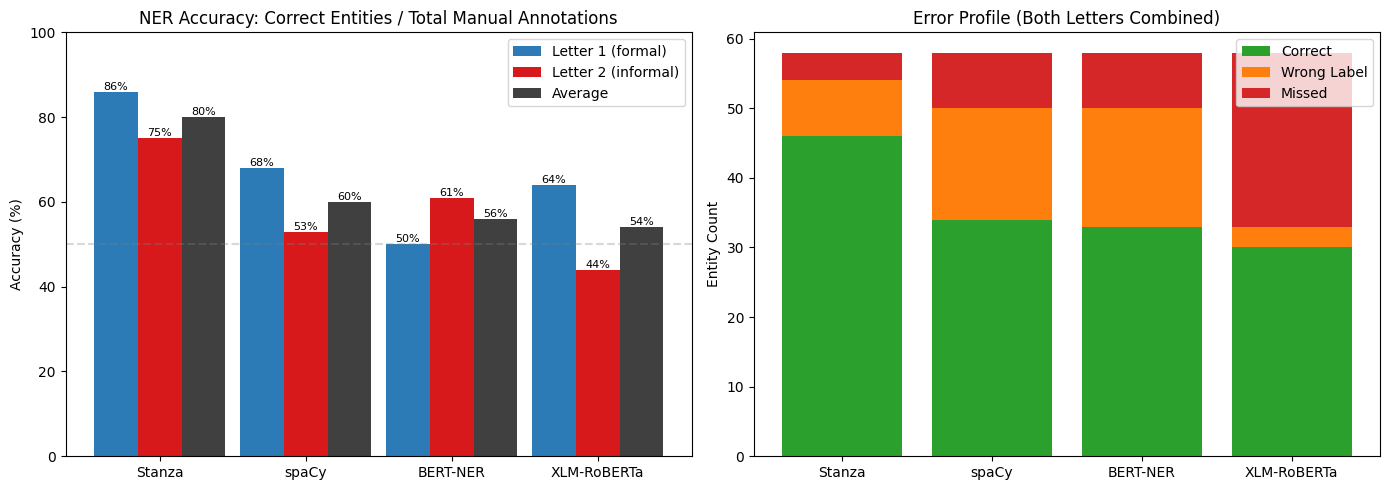

Plot saved to C:\Users\felip\Tesis\ner_comparison.png


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Stanza', 'spaCy', 'BERT-NER', 'XLM-RoBERTa']
letter1_acc = [86, 68, 50, 64]
letter2_acc = [75, 53, 61, 44]
avg_acc = [80, 60, 56, 54]

# Plot 1: Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(len(models))
width = 0.3
bars1 = axes[0].bar(x - width, letter1_acc, width, label='Letter 1 (formal)', color='#2c7bb6')
bars2 = axes[0].bar(x, letter2_acc, width, label='Letter 2 (informal)', color='#d7191c')
bars3 = axes[0].bar(x + width, avg_acc, width, label='Average', color='#404040')

axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('NER Accuracy: Correct Entities / Total Manual Annotations')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        axes[0].annotate(f'{bar.get_height():.0f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        ha='center', va='bottom', fontsize=8)

# Plot 2: Error profile
categories = ['Correct', 'Wrong Label', 'Missed']

# Letter 1 data
l1_data = {
    'Stanza':     [19, 2, 1],
    'spaCy':      [15, 7, 0],
    'BERT-NER':   [11, 11, 0],
    'XLM-RoBERTa':[14, 1, 7],
}
# Letter 2 data
l2_data = {
    'Stanza':     [27, 6, 3],
    'spaCy':      [19, 9, 8],
    'BERT-NER':   [22, 6, 8],
    'XLM-RoBERTa':[16, 2, 18],
}

# Combined (sum both letters)
combined = {}
for m in models:
    combined[m] = [l1_data[m][i] + l2_data[m][i] for i in range(3)]

colors = ['#2ca02c', '#ff7f0e', '#d62728']
bottoms = np.zeros(len(models))

for i, cat in enumerate(categories):
    vals = [combined[m][i] for m in models]
    axes[1].bar(models, vals, bottom=bottoms, label=cat, color=colors[i])
    bottoms += np.array(vals)

axes[1].set_ylabel('Entity Count')
axes[1].set_title('Error Profile (Both Letters Combined)')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\felip\Tesis\ner_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to C:\\Users\\felip\\Tesis\\ner_comparison.png")

## 10. Findings and Recommendation

## NER MODEL COMPARISON — FINAL RESULTS


Accuracy (correct / total manual entities):

  Model       Letter 1 (formal)    Letter 2 (informal)    Average
  Stanza      86%                  75%                    80%
  spaCy       68%                  53%                    60%
  BERT-NER    50%                  61%                    56%
  XLM-R       64%                  44%                    54%


## DETAILED PROFILE PER MODEL

STANZA — Best overall (80% avg)
  + Highest accuracy on both letters
  + Best at person recognition, including nicknames (Lucho, Duby, Roland)
  + Strongest with Latin American geography (Osorno, Yosemite)
  + Good balance: few missed, few wrong labels, low false positives
  - Struggles with ORG boundaries ("Legation de Chili" split)
  - Misses some cultural references (Axis, Los Camp Followers)

spaCy — Aggressive detector (60% avg)
  + Rarely misses entities (0 missed in Letter 1)
  + Good ORG detection ("Legation de Chili", "Rockefeller Committee")
  - Systematic PER→LOC confusion (Franica, Marta, Roland, Duby)
  - Highest false positive count (3-8 per letter)
  - Salutation confusion ("Dear Lucho" → ORG)

BERT-NER (dslim) — Conservative (56% avg)
  + Zero false positives on both letters
  + Confidence scores useful for filtering
  + Decent on Letter 2 (informal text)
  - Systematic label confusion: PER→LOC on non-English names
  - Misses Chilean geography (Villarrica, Osorno)
  - Trained on English news, not suited for historical correspondence

XLM-RoBERTa — Selective (54% avg)
  + When correct, very high confidence (most scores > 0.99)
  + Fewest wrong labels (1-2 per letter) — best label precision
  + Detects entities others miss (Sugar Bowl as LOC)
  + Multilingual advantage: detects "Villarica" that BERT misses
  - Misses the most entities overall (7-18 per letter)
  - Tokenization issues (merged words: "LuisMitrovich", "CapeCod")
  - Loses common entities other models catch (Austria, Reisser, Lucho)


## ORTHOGRAPHIC NOTE

  "Villarrica" vs "Villarica": The original letter text uses 
  "Villarica" (single r). The correct Chilean spelling is 
  "Villarrica" (double r). Both Stanza and XLM-R detected it 
  but the comparison showed ✗ due to this spelling mismatch. 
  This highlights a challenge specific to historical correspondence: 
  entity normalization must account for variant spellings.


## ALL MODELS FAIL ON

  - "Uncle Sam" as MISC — all classify as PER
  - "American embassy" as ORG — none get the full entity correct
  - Cultural/political groups: Axis, Allies (only BERT detects 
    these, but as MISC not ORG)
  - "Los Camp Followers" — no model classifies correctly


## RECOMMENDATION

  PRIMARY TOOL: Stanza
    Justification: highest accuracy, best person detection,
    handles multilingual names, good LOC coverage.

  SUPPLEMENTARY: spaCy as second pass for ORG detection.
    spaCy catches ORGs that Stanza misses or misclassifies.

  NOT RECOMMENDED as primary: BERT-NER and XLM-RoBERTa.
    Both underperform on historical correspondence with
    multilingual content and non-standard proper names.
    However, XLM-RoBERTa's low wrong-label rate suggests 
    potential value as a high-precision filter if recall 
    is supplemented by other tools.

  MANDATORY: Manual review of all NER output.
    No model exceeds 86% on these letters. For a corpus of 
    ~40 English letters, manual correction is feasible and 
    necessary for research-quality results.

## Post Supervision and Feedback from F. Pannach

- Standarize color and hex codes for all visualizations and panels
- Do a Precision, Recall and F1 in evaluation for model test.

In [2]:
# PRECISION, RECALL, F1 

# In standard NER evaluation, a wrong label counts as:
#   - a false positive (model produced an incorrect entity)
#   - a miss (the correct entity was not found with correct label)

results = {
    'spaCy': {
        'L1': {'correct': 15, 'wrong_label': 7, 'missed': 0, 'false_pos': 3},
        'L2': {'correct': 19, 'wrong_label': 9, 'missed': 8, 'false_pos': 8},
    },
    'Stanza': {
        'L1': {'correct': 19, 'wrong_label': 2, 'missed': 1, 'false_pos': 3},
        'L2': {'correct': 27, 'wrong_label': 6, 'missed': 3, 'false_pos': 4},
    },
    'BERT-NER': {
        'L1': {'correct': 11, 'wrong_label': 11, 'missed': 0, 'false_pos': 0},
        'L2': {'correct': 22, 'wrong_label': 6, 'missed': 8, 'false_pos': 0},
    },
    'XLM-RoBERTa': {
        'L1': {'correct': 14, 'wrong_label': 1, 'missed': 7, 'false_pos': 0},
        'L2': {'correct': 16, 'wrong_label': 2, 'missed': 18, 'false_pos': 1},
    },
}

def calc_metrics(d):
    c = d['correct']
    fp = d['false_pos'] + d['wrong_label']  # wrong label = false positive
    fn = d['missed'] + d['wrong_label']     # wrong label = missed correct
    precision = c / (c + fp) if (c + fp) > 0 else 0
    recall = c / (c + fn) if (c + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

rows = []
for model in results:
    for letter, label in [('L1', 'Letter 1 (S54)'), ('L2', 'Letter 2 (S35)')]:
        p, r, f = calc_metrics(results[model][letter])
        d = results[model][letter]
        rows.append({
            'Model': model, 'Letter': label,
            'Precision': f'{p:.2f}', 'Recall': f'{r:.2f}', 'F1': f'{f:.2f}',
            'Correct': d['correct'], 'Wrong Label': d['wrong_label'],
            'Missed': d['missed'], 'False Pos': d['false_pos'],
        })
    combined = {k: results[model]['L1'][k] + results[model]['L2'][k] 
                for k in ['correct', 'wrong_label', 'missed', 'false_pos']}
    p, r, f = calc_metrics(combined)
    rows.append({
        'Model': model, 'Letter': 'Average',
        'Precision': f'{p:.2f}', 'Recall': f'{r:.2f}', 'F1': f'{f:.2f}',
        'Correct': combined['correct'], 'Wrong Label': combined['wrong_label'],
        'Missed': combined['missed'], 'False Pos': combined['false_pos'],
    })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

      Model         Letter Precision Recall   F1  Correct  Wrong Label  Missed  False Pos
      spaCy Letter 1 (S54)      0.60   0.68 0.64       15            7       0          3
      spaCy Letter 2 (S35)      0.53   0.53 0.53       19            9       8          8
      spaCy        Average      0.56   0.59 0.57       34           16       8         11
     Stanza Letter 1 (S54)      0.79   0.86 0.83       19            2       1          3
     Stanza Letter 2 (S35)      0.73   0.75 0.74       27            6       3          4
     Stanza        Average      0.75   0.79 0.77       46            8       4          7
   BERT-NER Letter 1 (S54)      0.50   0.50 0.50       11           11       0          0
   BERT-NER Letter 2 (S35)      0.79   0.61 0.69       22            6       8          0
   BERT-NER        Average      0.66   0.57 0.61       33           17       8          0
XLM-RoBERTa Letter 1 (S54)      0.93   0.64 0.76       14            1       7          0
XLM-RoBERT

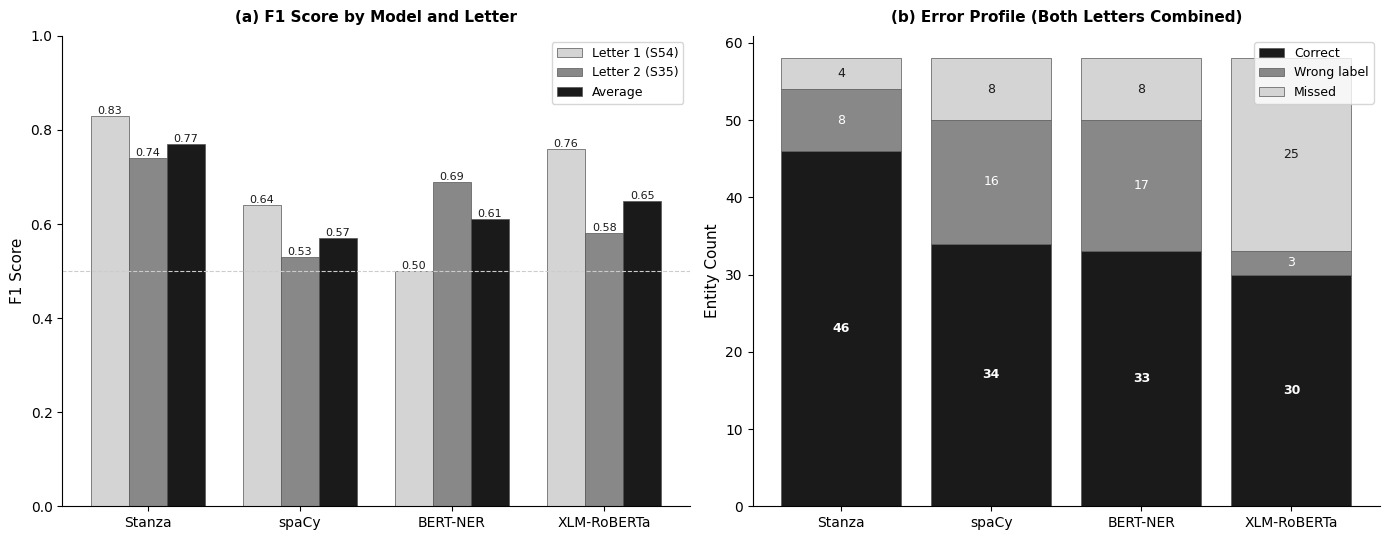

In [3]:
# FIG. 6: NER MODEL EVALUATION

# Color palette
C_LETTER1 = "#d4d4d4"
C_LETTER2 = "#888888"
C_AVERAGE = "#1a1a1a"

C_CORRECT = "#1a1a1a"
C_WRONG   = "#888888"
C_MISSED  = "#d4d4d4"

models = ['Stanza', 'spaCy', 'BERT-NER', 'XLM-RoBERTa']

# F1 scores
f1_l1 = [0.83, 0.64, 0.50, 0.76]
f1_l2 = [0.74, 0.53, 0.69, 0.58]
f1_avg = [0.77, 0.57, 0.61, 0.65]

# Error profile (combined both letters)
correct_vals  = [46, 34, 33, 30]
wrong_vals    = [8, 16, 17, 3]
missed_vals   = [4, 8, 8, 25]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: F1 Score comparison
ax = axes[0]
x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, f1_l1, width, label='Letter 1 (S54)', color=C_LETTER1, edgecolor='#555555', linewidth=0.5)
bars2 = ax.bar(x, f1_l2, width, label='Letter 2 (S35)', color=C_LETTER2, edgecolor='#555555', linewidth=0.5)
bars3 = ax.bar(x + width, f1_avg, width, label='Average', color=C_AVERAGE, edgecolor='#555555', linewidth=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        val = bar.get_height()
        color = 'white' if bar.get_facecolor()[:3] == (0.1, 0.1, 0.1) or bar.get_facecolor()[:3] == (26/255, 26/255, 26/255) else '#1a1a1a'
        ax.annotate(f'{val:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, val),
                    ha='center', va='bottom', fontsize=8, color='#1a1a1a')

ax.set_ylabel('F1 Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9, loc='upper right')
ax.axhline(y=0.5, color='#cccccc', linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('(a) F1 Score by Model and Letter', fontsize=11, fontweight='bold', pad=10)

# Panel B: Error profile (stacked)
ax = axes[1]
bottoms_w = np.array(correct_vals)
bottoms_m = bottoms_w + np.array(wrong_vals)

ax.bar(models, correct_vals, label='Correct', color=C_CORRECT, edgecolor='#555555', linewidth=0.5)
ax.bar(models, wrong_vals, bottom=correct_vals, label='Wrong label', color=C_WRONG, edgecolor='#555555', linewidth=0.5)
ax.bar(models, missed_vals, bottom=bottoms_m.tolist(), label='Missed', color=C_MISSED, edgecolor='#555555', linewidth=0.5)

# Add count labels inside bars
for i, model in enumerate(models):
    # Correct
    ax.text(i, correct_vals[i] / 2, str(correct_vals[i]), ha='center', va='center', 
            fontsize=9, fontweight='bold', color='white')
    # Wrong
    if wrong_vals[i] > 1:
        ax.text(i, correct_vals[i] + wrong_vals[i] / 2, str(wrong_vals[i]), 
                ha='center', va='center', fontsize=9, color='white')
    # Missed
    if missed_vals[i] > 1:
        ax.text(i, bottoms_m[i] + missed_vals[i] / 2, str(missed_vals[i]), 
                ha='center', va='center', fontsize=9, color='#1a1a1a')

ax.set_ylabel('Entity Count', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('(b) Error Profile (Both Letters Combined)', fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(FIGURES / "fig6_ner_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# EXPORT: Metrics table

# Clean table with only P, R, F1
export_rows = []
for model in ['Stanza', 'spaCy', 'BERT-NER', 'XLM-RoBERTa']:
    for letter, label in [('L1', 'Letter 1 (S54)'), ('L2', 'Letter 2 (S35)')]:
        d = results[model][letter]
        p, r, f = calc_metrics(d)
        export_rows.append({
            'Model': model, 'Letter': label,
            'Precision': round(p, 2), 'Recall': round(r, 2), 'F1': round(f, 2)
        })
    combined = {k: results[model]['L1'][k] + results[model]['L2'][k] 
                for k in ['correct', 'wrong_label', 'missed', 'false_pos']}
    p, r, f = calc_metrics(combined)
    export_rows.append({
        'Model': model, 'Letter': 'Average',
        'Precision': round(p, 2), 'Recall': round(r, 2), 'F1': round(f, 2)
    })

export_df = pd.DataFrame(export_rows)

# Pivot for format
pivot = export_df.pivot(index='Model', columns='Letter', values=['Precision', 'Recall', 'F1'])

# Reorder
model_order = ['Stanza', 'spaCy', 'BERT-NER', 'XLM-RoBERTa']
letter_order = ['Letter 1 (S54)', 'Letter 2 (S35)', 'Average']
pivot = pivot.reindex(model_order)
pivot = pivot.reindex(letter_order, axis=1, level=1)

print(pivot.to_string())

# Save to CSV
df_metrics.to_csv(DATA_PROC / "ner_evaluation_metrics.csv", index=False)
print("\nSaved to ner_metrics_table.csv")

                 Precision                                Recall                                    F1                       
Letter      Letter 1 (S54) Letter 2 (S35) Average Letter 1 (S54) Letter 2 (S35) Average Letter 1 (S54) Letter 2 (S35) Average
Model                                                                                                                        
Stanza                0.79           0.73    0.75           0.86           0.75    0.79           0.83           0.74    0.77
spaCy                 0.60           0.53    0.56           0.68           0.53    0.59           0.64           0.53    0.57
BERT-NER              0.50           0.79    0.66           0.50           0.61    0.57           0.50           0.69    0.61
XLM-RoBERTa           0.93           0.84    0.88           0.64           0.44    0.52           0.76           0.58    0.65

Saved to ner_metrics_table.csv
